In [112]:
import torch

weight = 0.7;
bias = 0.5;

start = 0
step = 1
end = 100

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

In [113]:
X, y

(tensor([[ 0],
         [ 1],
         [ 2],
         [ 3],
         [ 4],
         [ 5],
         [ 6],
         [ 7],
         [ 8],
         [ 9],
         [10],
         [11],
         [12],
         [13],
         [14],
         [15],
         [16],
         [17],
         [18],
         [19],
         [20],
         [21],
         [22],
         [23],
         [24],
         [25],
         [26],
         [27],
         [28],
         [29],
         [30],
         [31],
         [32],
         [33],
         [34],
         [35],
         [36],
         [37],
         [38],
         [39],
         [40],
         [41],
         [42],
         [43],
         [44],
         [45],
         [46],
         [47],
         [48],
         [49],
         [50],
         [51],
         [52],
         [53],
         [54],
         [55],
         [56],
         [57],
         [58],
         [59],
         [60],
         [61],
         [62],
         [63],
         [64],
         [65],
         [

In [114]:
train_test_split = int(0.8 * 100)

X_train, X_test = X[:train_test_split], X[train_test_split:]
y_train, y_test = y[:train_test_split], y[train_test_split:]

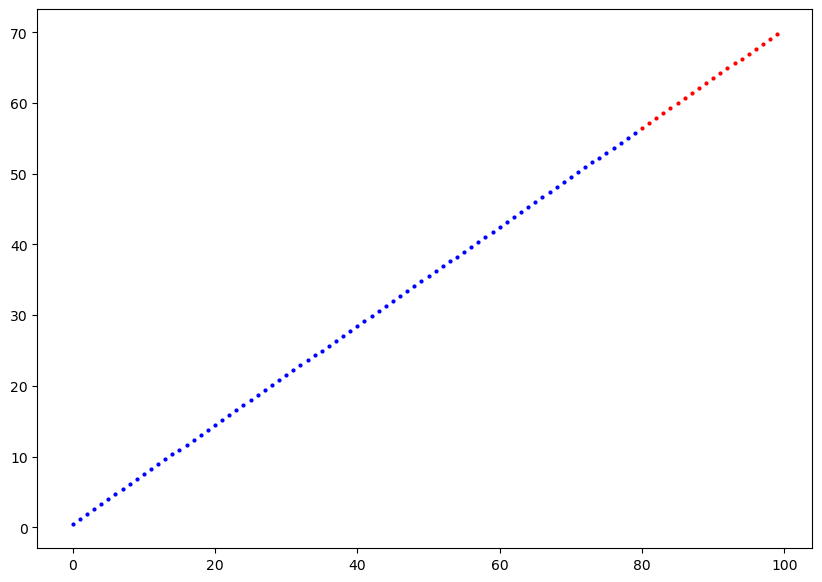

In [115]:
from matplotlib import pyplot as pt

def plot_predictions(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, predictions=None, train_preds=None):
    pt.figure(figsize=(10, 7))
    pt.scatter(X_train, y_train, s=4, c='b', label="train")

    pt.scatter(X_test, y_test, s=4, c='r', label="test")

    if predictions is not None:
        pt.scatter(X_test.detach().numpy(), predictions.detach().numpy(), s=4, c='r', label="test")
    
    if train_preds is not None:
        pt.scatter(X_train.detach().numpy(), train_preds.detach().numpy(), s=4, c='b', label="train")

plot_predictions(X_train, y_train=y_train, X_test=X_test, y_test=y_test)

In [152]:
from torch import nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))

    def forward(self, x: torch.tensor) -> torch.Tensor:
        return self.weight * x + self.bias

model_0 = LinearRegressionModel()

In [162]:
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.003)
loss_fn = nn.L1Loss()

In [163]:
epochs = 10000

X_train_pred = []
loss_values = []
test_loss_values = []


for epoch in range(epochs):
    optimizer.zero_grad()

    model_0.train()

    y_preds = model_0(X_train)

    loss = loss_fn(y_preds, y_train)

    loss.backward()

    optimizer.step()

    with torch.inference_mode():
        y_test_preds = model_0(X_test)
        test_loss = loss_fn(y_test_preds, y_test)
    
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
        print(model_0.state_dict())

Epoch: 0 | Loss: 0.02560368739068508 | Test Loss: 10.551995277404785
OrderedDict([('weight', tensor([0.5821])), ('bias', tensor([0.4980]))])
Epoch: 10 | Loss: 0.02560368739068508 | Test Loss: 10.551995277404785
OrderedDict([('weight', tensor([0.5821])), ('bias', tensor([0.4980]))])
Epoch: 20 | Loss: 0.02560368739068508 | Test Loss: 10.551995277404785
OrderedDict([('weight', tensor([0.5821])), ('bias', tensor([0.4980]))])
Epoch: 30 | Loss: 0.02560368739068508 | Test Loss: 10.551995277404785
OrderedDict([('weight', tensor([0.5821])), ('bias', tensor([0.4980]))])
Epoch: 40 | Loss: 0.02560368739068508 | Test Loss: 10.551995277404785
OrderedDict([('weight', tensor([0.5821])), ('bias', tensor([0.4980]))])
Epoch: 50 | Loss: 0.02560368739068508 | Test Loss: 10.551995277404785
OrderedDict([('weight', tensor([0.5821])), ('bias', tensor([0.4980]))])
Epoch: 60 | Loss: 0.02560368739068508 | Test Loss: 10.551995277404785
OrderedDict([('weight', tensor([0.5821])), ('bias', tensor([0.4980]))])
Epoch: 

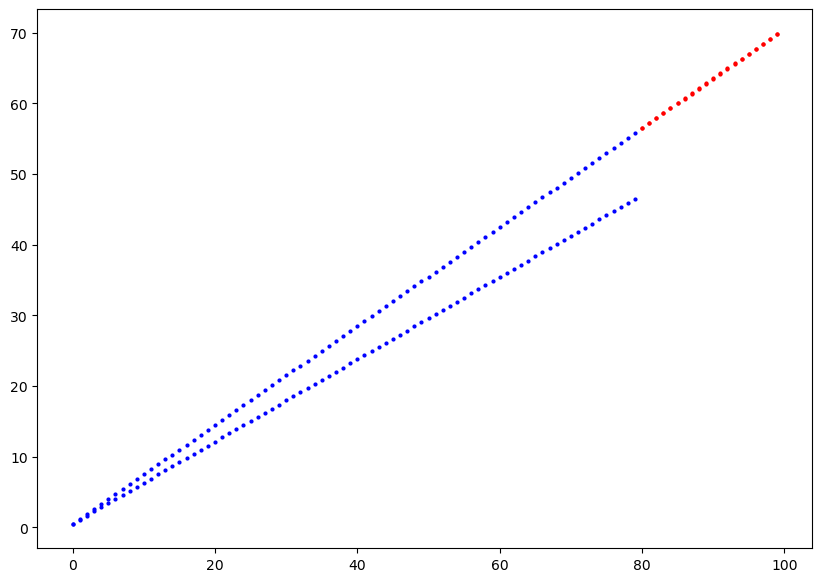

In [164]:
plot_predictions(predictions=y_test_preds, train_preds=y_preds)